77/77 [==============================] - 5s 19ms/step - loss: 7.8492e-04 - val_loss: 5.3758e-04
Model: "sequential_53"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM_2 (LSTM)               (None, 1, 256)            267264    
                                                                 
 LSTM_1 (LSTM)               (None, 128)               197120    
                                                                 
 Denser (Dense)              (None, 64)                8256      
                                                                 
 Dense_1 (Dense)             (None, 32)                2080      
                                                                 
 Dense_2 (Dense)             (None, 16)                528       
                                                                 
 Dense_3 (Dense)             (None, 8)                 136       
                       

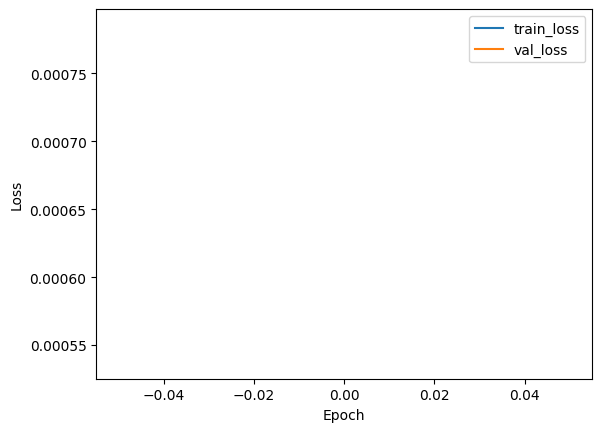

26/26 [==============================] - 0s 4ms/step - loss: 6.9911e-04
Test Loss: 0.0006991060799919069


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Normalization, Dropout, LSTM
from keras.losses import MeanSquaredError
from keras.optimizers import Adam

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

cols_to_use = [1,2,3,4]

nifty_symbols = [
    "ADANIPORTS", "ASIANPAINT", "AXISBANK", "BAJAJ-AUTO", "BAJAJFINSV",
    "BAJFINANCE", "BPCL", "BRITANNIA", "CIPLA", "COALINDIA",
    "DIVISLAB", "DRREDDY", "EICHERMOT", "GRASIM", "HCLTECH",
    "HDFCBANK", "HDFCLIFE", "HEROMOTOCO", "HINDALCO", "HINDUNILVR",
    "ICICIBANK", "ICICIGI", "IOC", "INDUSINDBK", "INFY",
    "ITC", "JSWSTEEL", "KOTAKBANK", "LTTS", "LT",
    "M&M", "MARICO", "MARUTI", "NESTLEIND"
]

for symbol in nifty_symbols:
  data = np.genfromtxt(f'{symbol}.csv', delimiter=',', skip_header=1)

  X = data[:,:-1]
  Y = data[:,-1]

  cv_index = int(0.6 * len(X))
  test_index = int(0.8 * len(X))

  X_train, X_val, X_test = X[:cv_index], X[cv_index:test_index], X[test_index:]
  Y_train, Y_val, Y_test = Y[:cv_index], Y[cv_index:test_index], Y[test_index:]

  X_train = X_train[:, cols_to_use]
  X_val = X_val[:, cols_to_use]
  X_test = X_test[:, cols_to_use]

  # Normalize the features
  norm_l = Normalization(axis=-1)
  norm_l.adapt(X_train)
  X_train_n = norm_l(X_train)
  X_val_n = norm_l(X_val)
  X_test_n = norm_l(X_test)

  # Reshape the data for LSTM
  X_train_n = tf.reshape(X_train_n, (X_train_n.shape[0], 1, X_train_n.shape[1]))
  X_val_n = tf.reshape(X_val_n, (X_val_n.shape[0], 1, X_val_n.shape[1]))
  X_test_n = tf.reshape(X_test_n, (X_test_n.shape[0], 1, X_test_n.shape[1]))

  tf.random.set_seed(42)

  # Define the LSTM model
  model = Sequential(
      [
          Input(shape=(1, 4)),
          LSTM(256, activation='relu', name="LSTM_2", return_sequences=True),
          LSTM(128, activation='relu', name="LSTM_1"),
          Dense(64, activation='relu', name="Denser"),
          Dense(32, activation='relu', name="Dense_1"),
          Dense(16, activation='relu', name="Dense_2"),
          Dense(8, activation='relu', name="Dense_3"),
          Dense(1, activation='tanh', name="Output")
      ]
  )

  # Compile the model with mean squared error loss for regression
  model.compile(optimizer='adam', loss='mean_squared_error')

  # Train the model
  history = model.fit(X_train_n, Y_train, validation_data=(X_val_n, Y_val), epochs=1, batch_size=32)

  model.save(f'{symbol}_model.h5')

  # Print the model summary
  model.summary()

# # Plot the training and validation loss
# plt.plot(history.history['loss'], label='train_loss')
# plt.plot(history.history['val_loss'], label='val_loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

# # Evaluate the model on the test set
# test_loss = model.evaluate(X_test_n, Y_test)
# print(f'Test Loss: {test_loss}')

# # Predict on the test set
# Y_pred = model.predict(X_test_n)

# # Printing original and predicted values
# for i in range(len(Y_pred)):
#     print(f"Original: {Y_test[i]}, Predicted: {Y_pred[i][0]}")
